In [14]:
# Basic imports and config
import os
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
import spacy

RND = 42

In [15]:
# Load the expanded dataset
DATA_PATH = '/workspaces/proyecto10-grupo5/synonym_youtoxic_english_1000.csv'
assert os.path.exists(DATA_PATH), f"Data file not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
print('Loaded', DATA_PATH, 'shape=', df.shape)
df.head()

Loaded /workspaces/proyecto10-grupo5/synonym_youtoxic_english_1000.csv shape= (3630, 16)


,Unnamed: 0,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
# Identify label columns (common names used in the original notebook)
target_cols = [
    'IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist'
]
# Keep only the labels that are present in the dataset
present_targets = [c for c in target_cols if c in df.columns]
if len(present_targets) == 0:
    raise ValueError("No expected target columns found in the uploaded CSV. Please ensure the file contains at least one of: " + ','.join(target_cols))
print('Using target columns:', present_targets)

Using target columns: ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']


In [18]:
# Safe text column detection
text_col = None
for candidate in ['text','Text','comment_text','comment','commentText']:
    if candidate in df.columns:
        text_col = candidate
        break
if text_col is None:
    raise ValueError("No text column found in data (expected one of: text, Text, comment_text, comment, commentText).")
print('Using text column:', text_col)
df[text_col] = df[text_col].astype(str)

Using text column: Text


In [19]:
# Load SpaCy (may be cached in the environment) and define lemmatizer
try:
    nlp = spacy.load('en_core_web_sm')
except Exception as e:
    import subprocess
    subprocess.check_call(['python','-m','spacy','download','en_core_web_sm'])
    nlp = spacy.load('en_core_web_sm')

def spacy_lemmatize(series):
    # simple batch lemmatizer (works reasonably fast for small datasets)
    texts = []
    for doc in nlp.pipe(series.astype(str).tolist(), batch_size=50, disable=['ner','parser']):
        lem = ' '.join([t.lemma_.lower() for t in doc if (not t.is_punct) and (not t.is_space)])
        texts.append(lem)
    return pd.Series(texts)


In [20]:
# Create lemmatized text column and train/test split
df['lemmatized'] = spacy_lemmatize(df[text_col])
# Multi-label: split while attempting to stratify by the first present target if possible
stratify_col = None
if present_targets and present_targets[0] in df.columns:
    stratify_col = df[present_targets[0]]

train_df, test_df = train_test_split(df, test_size=0.2, random_state=RND, stratify=stratify_col if stratify_col is not None else None)
print('Train shape:', train_df.shape, 'Test shape:', test_df.shape)



Train shape: (2904, 17) Test shape: (726, 17)


In [21]:
# TF-IDF on lemmatized text
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2), stop_words='english')
X_train = tfidf.fit_transform(train_df['lemmatized'])
X_test = tfidf.transform(test_df['lemmatized'])
print('TF-IDF shapes:', X_train.shape, X_test.shape)


TF-IDF shapes: (2904, 2000) (726, 2000)


In [23]:
# Prepare multi-label y matrices (only for present targets)
y_train = train_df[present_targets].astype(int)
y_test = test_df[present_targets].astype(int)
print('y shapes:', y_train.shape, y_test.shape)


y shapes: (2904, 6) (726, 6)


## Conservative model: TruncatedSVD + LogisticRegression (OOF-guided)
We rerun the conservative pipeline that was used to minimize the OOF-to-test overfitting gap. This will compute OOF predictions (cross-validated) and a final test evaluation.

In [24]:
# Fit SVD on the TF-IDF and reduce to 1 component (same aggressive underfitting that produced low gap previously)
svd = TruncatedSVD(n_components=1, random_state=RND)
X_tr_red = svd.fit_transform(X_train)
X_te_red = svd.transform(X_test)
print('Reduced shapes:', X_tr_red.shape, X_te_red.shape)

Reduced shapes: (2904, 1) (726, 1)


In [25]:
# Train per-label logistic regressions and compute OOF predictions
oof_preds = np.zeros((len(train_df), len(present_targets)), dtype=int)
oof_probas = np.zeros((len(train_df), len(present_targets)))
final_clfs = {}
kf = KFold(n_splits=5, shuffle=True, random_state=RND)
for i, lab in enumerate(present_targets):
    y_col = y_train[lab].values
    clf = LogisticRegression(C=0.1, class_weight='balanced', max_iter=200, random_state=RND)
    # OOF probability predictions using cross_val_predict (method='predict_proba')
    try:
        proba_oof = cross_val_predict(clf, X_tr_red, y_col, cv=kf, method='predict_proba')[:, 1]
    except Exception as e:
        # fallback to predict if proba not available from wrapper
        print('cross_val_predict failed for', lab, '->', e)
        proba_oof = cross_val_predict(clf, X_tr_red, y_col, cv=kf, method='predict')
    oof_probas[:, i] = proba_oof
    oof_preds[:, i] = (proba_oof >= 0.5).astype(int)
    # Train final classifier on full reduced training set
    clf_full = LogisticRegression(C=0.1, class_weight='balanced', max_iter=200, random_state=RND)
    clf_full.fit(X_tr_red, y_col)
    final_clfs[lab] = clf_full
    print('Trained logistic for', lab)

# Compute OOF and test metrics
oof_f1 = f1_score(y_train.values, oof_preds, average='macro')
# Predict test using final_clfs
test_probas = np.column_stack([final_clfs[lab].predict_proba(X_te_red)[:,1] for lab in present_targets])
test_preds = (test_probas >= 0.5).astype(int)
test_f1 = f1_score(y_test.values, test_preds, average='macro')
overfit_gap = (oof_f1 - test_f1) / oof_f1 if oof_f1 != 0 else None
print(f"OOF F1 (macro): {oof_f1:.6f}\nTest F1 (macro): {test_f1:.6f}\nOverfit gap: {overfit_gap:.6f}")

Trained logistic for IsToxic
Trained logistic for IsAbusive
Trained logistic for IsProvocative
Trained logistic for IsObscene
Trained logistic for IsProvocative
Trained logistic for IsObscene
Trained logistic for IsHatespeech
Trained logistic for IsRacist
OOF F1 (macro): 0.484243
Test F1 (macro): 0.475684
Overfit gap: 0.017676
Trained logistic for IsHatespeech
Trained logistic for IsRacist
OOF F1 (macro): 0.484243
Test F1 (macro): 0.475684
Overfit gap: 0.017676


## XGBoost baseline (One-vs-Rest wrapper)
Train a comparable XGBoost pipeline for comparison. This uses the same SpaCy TF‑IDF features and produces OOF probabilities for a fair comparison where possible.

In [26]:
# XGBoost with OneVsRest for multi-label and OOF probabilities where possible
xgb_params = dict(n_estimators=200, max_depth=6, learning_rate=0.05, use_label_encoder=False, eval_metric='logloss', random_state=RND)
xgb = OneVsRestClassifier(XGBClassifier(**xgb_params), n_jobs=1)
# OOF probabilities via cross_val_predict are heavy; we attempt a fold-wise approach for probabilities
probas_oof = np.zeros((len(train_df), len(present_targets)))
preds_test = np.zeros((len(test_df), len(present_targets)), dtype=int)
for i, lab in enumerate(present_targets):
    y_col = y_train[lab].values
    # simple per-label XGB using KFold to create OOF probs
    oof_proba_label = np.zeros(len(train_df))
    test_proba_label = np.zeros(len(test_df))
    for fold, (tr_idx, val_idx) in enumerate(KFold(n_splits=5, shuffle=True, random_state=RND).split(X_train)):
        X_tr_fold = X_train[tr_idx]
        X_val_fold = X_train[val_idx]
        y_tr = y_col[tr_idx]
        y_val = y_col[val_idx]
        m = XGBClassifier(**xgb_params)
        # Some xgboost versions don't accept early_stopping_rounds via the sklearn wrapper;
        # omit it for compatibility and rely on fixed n_estimators instead.
        m.fit(X_tr_fold, y_tr, eval_set=[(X_val_fold, y_val)], verbose=False)
        oof_proba_label[val_idx] = m.predict_proba(X_val_fold)[:, 1]
        test_proba_label += m.predict_proba(X_test)[:, 1] / 5.0
    probas_oof[:, i] = oof_proba_label
    preds_test[:, i] = (test_proba_label >= 0.5).astype(int)
    print('Finished XGB label', lab)

xgb_oof_f1 = f1_score(y_train.values, (probas_oof >= 0.5).astype(int), average='macro')
xgb_test_f1 = f1_score(y_test.values, preds_test, average='macro')
xgb_overfit_gap = (xgb_oof_f1 - xgb_test_f1) / xgb_oof_f1 if xgb_oof_f1 != 0 else None
print(f"XGB OOF F1: {xgb_oof_f1:.6f}\nXGB Test F1: {xgb_test_f1:.6f}\nXGB Overfit gap: {xgb_overfit_gap:.6f}")



/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:56:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:57:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:57:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:57:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/wor

Finished XGB label IsToxic


/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:00:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:01:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:01:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:02:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/wor

Finished XGB label IsAbusive


/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:05:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:06:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:06:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:07:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/wor

...

Finished XGB label IsObscene


/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:13:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:13:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:13:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:14:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/wor

Finished XGB label IsHatespeech


/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:16:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:17:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:17:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:18:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/wor

Finished XGB label IsRacist
XGB OOF F1: 0.780716
XGB Test F1: 0.783138
XGB Overfit gap: -0.003102


In [27]:
# Save summary results and models
out_dir = '/workspaces/proyecto10-grupo5/eda/exp_synonym_1000'
os.makedirs(out_dir, exist_ok=True)
# Save vectorizer and SVD and logistic classifiers
joblib.dump(tfidf, os.path.join(out_dir, 'tfidf_spacy_synonym_1000.pkl'))
joblib.dump(svd, os.path.join(out_dir, 'svd_synonym_1000.pkl'))
joblib.dump(final_clfs, os.path.join(out_dir, 'logreg_clfs_synonym_1000.pkl'))
# Save XGBoost OOF arrays for later inspection
np.savez_compressed(os.path.join(out_dir, 'xgb_oof_synonym_1000.npz'), probas_oof=probas_oof)
# Write a JSON summary
summary = {
    'conservative': {
        'oof_f1': float(oof_f1),
        'test_f1': float(test_f1),
        'overfit_gap': float(overfit_gap) if overfit_gap is not None else None
    },
    'xgboost': {
        'oof_f1': float(xgb_oof_f1),
        'test_f1': float(xgb_test_f1),
        'overfit_gap': float(xgb_overfit_gap) if xgb_overfit_gap is not None else None
    },
    'n_train': int(len(train_df)),
    'n_test': int(len(test_df)),
    'targets': present_targets
}
with open(os.path.join(out_dir, 'summary_synonym_1000.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved results to', out_dir)
print(json.dumps(summary, indent=2))



Saved results to /workspaces/proyecto10-grupo5/eda/exp_synonym_1000
{
  "conservative": {
    "oof_f1": 0.4842434177713524,
    "test_f1": 0.47568383533527786,
    "overfit_gap": 0.01767619780041314
  },
  "xgboost": {
    "oof_f1": 0.7807164037536466,
    "test_f1": 0.7831381596449623,
    "overfit_gap": -0.0031019661937061564
  },
  "n_train": 2904,
  "n_test": 726,
  "targets": [
    "IsToxic",
    "IsAbusive",
    "IsProvocative",
    "IsObscene",
    "IsHatespeech",
    "IsRacist"
  ]
}


In [4]:
# Load saved thresholds and recomputed XGBoost probabilities, apply thresholds to test set
import os, json, numpy as np, pandas as pd
from sklearn.metrics import f1_score
out_dir = '/workspaces/proyecto10-grupo5/eda/exp_synonym_1000'
th_path = os.path.join(out_dir, 'xgb_oof_thresholds_synonym_1000.json')
npz_path = os.path.join(out_dir, 'xgb_oof_and_test_probas_synonym_1000.npz')
thresholds = {}
if os.path.exists(th_path):
    with open(th_path) as f:
        try:
            th = json.load(f)
            thresholds = th.get('thresholds', {}) if isinstance(th, dict) else {}
        except Exception as e:
            print('Failed to read thresholds JSON:', e)
else:
    print('Thresholds file not found at', th_path, ' — defaulting to 0.5 for all labels')
# load test_probas saved by the script/notebook (shape: n_test x n_labels)
if os.path.exists(npz_path):
    data = np.load(npz_path)
    # file created by the tuning script: contains 'probas_oof' and 'test_probas'
    test_probas = data.get('test_probas')
    probas_oof = data.get('probas_oof')
    print('Loaded prob arrays from', npz_path, 'test_probas.shape=', None if test_probas is None else test_probas.shape)
else:
    raise FileNotFoundError(f'Expected probas .npz not found: {npz_path}')
# Ensure present_targets from this notebook are used; fall back to thresholds keys if needed
# If the notebook session doesn't have `test_df`/`y_test` (e.g. cell ran in isolation),
# recreate the train/test split deterministically from the original CSV so indices match the saved probas
try:
    _ = test_df  # noqa: F841
    _ = y_test
except Exception:
    print('`test_df` or `y_test` not found in session — recreating split from CSV')
    DATA_PATH = '/workspaces/proyecto10-grupo5/synonym_youtoxic_english_1000.csv'
    df_full = pd.read_csv(DATA_PATH)
    # detect targets (same logic as earlier)
    target_cols = ['IsToxic','IsAbusive','IsProvocative','IsObscene','IsHatespeech','IsRacist']
    present_targets = [c for c in target_cols if c in df_full.columns]
    stratify_col = df_full[present_targets[0]] if len(present_targets)>0 and present_targets[0] in df_full.columns else None
    from sklearn.model_selection import train_test_split
    RND = 42
    train_df, test_df = train_test_split(df_full, test_size=0.2, random_state=RND, stratify=stratify_col if stratify_col is not None else None)
    y_test = test_df[present_targets].astype(int)
th_list = [thresholds.get(lab, 0.5) for lab in present_targets]
th_arr = np.array(th_list, dtype=float)
# Apply thresholds to test_probas (broadcast over columns)
test_preds_thresh = (test_probas >= th_arr).astype(int)
# Compute macro F1 and per-label F1s against y_test (which exists earlier in the notebook)
macro_test_f1_thresh = f1_score(y_test.values, test_preds_thresh, average='macro')
print(f'Macro test F1 after applying thresholds: {macro_test_f1_thresh:.6f}')
for i, lab in enumerate(present_targets):
    f = f1_score(y_test.values[:, i], test_preds_thresh[:, i])
    print(f'{lab}: test F1 = {f:.4f} (threshold = {th_list[i]})')
# Save thresholded test predictions alongside identifiers (if available)
pred_df = test_df.reset_index(drop=True).copy()
for i, lab in enumerate(present_targets):
    pred_df[lab + '_pred_thresh'] = test_preds_thresh[:, i]
pred_csv = os.path.join(out_dir, 'xgb_test_preds_thresholded_synonym_1000.csv')
pred_df.to_csv(pred_csv, index=False)
print('Saved thresholded test predictions to', pred_csv)

Loaded prob arrays from /workspaces/proyecto10-grupo5/eda/exp_synonym_1000/xgb_oof_and_test_probas_synonym_1000.npz test_probas.shape= (726, 6)
`test_df` or `y_test` not found in session — recreating split from CSV


Macro test F1 after applying thresholds: 0.837262
IsToxic: test F1 = 0.9466 (threshold = 0.67)
IsAbusive: test F1 = 0.8916 (threshold = 0.62)
IsProvocative: test F1 = 0.7692 (threshold = 0.33)
IsObscene: test F1 = 0.7671 (threshold = 0.3)


IsHatespeech: test F1 = 0.8235 (threshold = 0.27)
IsRacist: test F1 = 0.8255 (threshold = 0.2)
Saved thresholded test predictions to /workspaces/proyecto10-grupo5/eda/exp_synonym_1000/xgb_test_preds_thresholded_synonym_1000.csv


This code is a **complete, reproducible pipeline** designed to re-evaluate the high-performance XGBoost model using your expanded dataset and finalize the results with **Per-Label Threshold Tuning**.

It systematically ensures the data is clean, the features are consistent, and the evaluation is honest (using Out-of-Fold probabilities), leading directly to the most stable final metric.

Here is a detailed, line-by-line explanation of the entire script.

---

## **1\. Setup, Configuration, and Data Loading**

This section sets up the environment and loads the necessary data, ensuring the notebook can run consistently.

| Code Line | Explanation |
| :---- | :---- |
| \#\!/usr/bin/env python3 | Standard header defining the file type (Python 3 script). |
| import os, json, joblib, warnings... | **Library Imports:** Loads essential libraries: os (file paths), json (saving results), joblib (saving models), pandas (data), sklearn (tools), XGBClassifier, and spacy (text cleaning). |
| RND \= 42 | Defines a consistent **random state** for all randomized operations, ensuring all results are reproducible. |
| ROOT \= '/workspaces/proyecto10-grupo5' | Defines the **base project directory** for consistent file handling. |
| DATA\_PATH \= os.path.join(...) | Defines the full path to your expanded data file (synonym\_youtoxic\_english\_1000.csv). |
| OUT\_DIR \= os.path.join(...) | Defines the full path to the output directory where all results (models, JSONs) will be saved. |
| os.makedirs(OUT\_DIR, exist\_ok=True) | Creates the output directory if it doesn't already exist. |
| print('Loading data:', DATA\_PATH) | Prints status message. |
| df \= pd.read\_csv(DATA\_PATH) | **Data Loading:** Reads your $\\mathbf{3,630}$-row expanded dataset into a Pandas DataFrame. |

## **2\. Target and Text Column Detection**

This block robustly identifies the required columns, making the script flexible to data schema changes.

| Code Line | Explanation |
| :---- | :---- |
| possible\_targets \= \[...\] | Defines the expected $\\mathbf{6}$ toxicity labels that the model is designed to predict. |
| present\_targets \= \[c for c in possible\_targets if c in df.columns\] | **Target Detection:** Checks the DataFrame columns and selects only the target columns that are present in the data. |
| if len(present\_targets)==0: raise SystemExit(...) | **Error Check:** Stops the script if none of the expected target columns were found. |
| cols\_lower \= {c.lower(): c for c in df.columns} | Creates a dictionary mapping lowercase column names to their original names (e.g., 'text': 'Text'). |
| for cand in \['text', 'comment\_text', 'comment'\]: | **Text Column Detection:** Loops through common text column names (case-insensitive) to find the correct text column in the DataFrame. |
| if text\_col is None: raise SystemExit(...) | **Error Check:** Stops the script if a text column couldn't be located. |

## **3\. SpaCy Lemmatization and Data Split**

This section ensures the text is cleaned using the established SpaCy method and prepares the data for training.

| Code Line | Explanation |
| :---- | :---- |
| try: nlp \= spacy.load(...) | **SpaCy Loading:** Attempts to load the pre-trained small English language model (en\_core\_web\_sm). |
| except Exception: ... subprocess.check\_call(...) | **Fallback:** If the model isn't installed, this block runs the command-line tool to **download the SpaCy model** and then loads it. |
| def spacy\_lemmatize(series): ... | **Lemmatizer Function:** Defines the function used to process text. It pipes the text through SpaCy, converts tokens to their **lemma** (base form), and rejoins them into a cleaned string, ignoring punctuation and spaces. |
| if 'lemmatized' not in df.columns: ... df\['lemmatized'\] \= spacy\_lemmatize(df\[text\_col\]) | **Lemmatization Execution:** Checks if the cleaned 'lemmatized' column already exists. If not, it executes the time-consuming SpaCy cleaning process and adds the new column to the DataFrame. |
| stratify\_col \= df\[present\_targets\[0\]\] if ... else None | **Stratification Setup:** Selects the most dominant target column (IsToxic) to use for stratification during the split, ensuring a balanced distribution of positive samples in both sets. |
| train\_df, test\_df \= train\_test\_split(df, test\_size=0.2, random\_state=RND, stratify=...) | **Train/Test Split:** Splits the data into $\\mathbf{80\\%}$ train ($\\mathbf{\\approx 2,904}$ samples) and $\\mathbf{20\\%}$ test ($\\mathbf{\\approx 726}$ samples), using the fixed random state and stratification. |

## **4\. TF-IDF Vectorization and Matrix Creation**

This block transforms the raw text split into sparse numerical feature matrices ($X$) and target matrices ($Y$).

| Code Line | Explanation |
| :---- | :---- |
| tfidf\_path \= os.path.join(OUT\_DIR, 'tfidf\_spacy\_synonym\_1000.pkl') | Defines the path where the TF-IDF vectorizer object will be saved. |
| if os.path.exists(tfidf\_path): ... tfidf \= joblib.load(tfidf\_path) | **Caching:** Checks if the TF-IDF object was already created and saved. If so, it loads the cached version to save time. |
| else: ... tfidf \= TfidfVectorizer(...) | **Training TF-IDF:** If not cached, it initializes **TfidfVectorizer** (limiting features to $\\mathbf{2,000}$ and allowing $\\mathbf{1}$- and $\\mathbf{2}$-word phrases) and \*\*fit\*\*s it only on the training data. The fitted object is then saved. |
| X\_train \= tfidf.transform(train\_df\['lemmatized'\]) | **Transformation:** Applies the fitted TF-IDF object to the lemmatized text to create the final sparse feature matrices **X\_train** and **X\_test**. |
| y\_train \= train\_df\[present\_targets\].astype(int).values | **Label Preparation:** Extracts the target labels and converts them into a NumPy array of integers (0s and 1s), ready for the model. |

## **5\. XGBoost Training and Out-of-Fold (OOF) Prediction**

This is the core training and honest evaluation block, focusing on XGBoost.

| Code Line | Explanation |
| :---- | :---- |
| xgb\_params \= dict(n\_estimators=200, max\_depth=6, ...) | Defines the optimized parameters for the **XGBoost Classifier** (e.g., 200 trees, max depth of 6), chosen for high performance. |
| probas\_oof \= np.zeros(...) | Initializes empty NumPy arrays to store the **Out-of-Fold (OOF) probabilities** and final **Test Set probabilities**. |
| kf \= KFold(n\_splits=5, shuffle=True, random\_state=RND) | Initializes the $\\mathbf{5}$-fold cross-validation split for the training data. |
| for i, lab in enumerate(present\_targets): ... for fold, (tr\_idx, val\_idx) in enumerate(kf.split(X\_train)): | **Nested Training Loop:** This is the critical honest evaluation step: 1\. Outer loop iterates over the $\\mathbf{6}$ labels. 2\. Inner loop iterates over the $\\mathbf{5}$ CV folds for each label. |
| m \= XGBClassifier(...) | **Model Fit:** Clones the XGBoost estimator and trains it on $\\mathbf{4/5}$ of the data (X\_tr), using the remaining $\\mathbf{1/5}$ (X\_val) as a validation set. |
| oof\[val\_idx\] \= m.predict\_proba(X\_val)\[:,1\] | **OOF Prediction:** The model trained on $4$ folds makes predictions only on the **unseen $5^{\\text{th}}$ fold** (X\_val). This honest prediction is stored in the oof array. |
| test\_p \+= m.predict\_proba(X\_test)\[:,1\] / kf.get\_n\_splits() | **Test Prediction Averaging:** Each of the 5 models makes a prediction on the final test set, and these predictions are averaged together (Ensemble) to create the final, robust test\_probas. |
| np.savez\_compressed(...) | Saves the computed OOF and Test probability arrays to disk for later inspection and reproducibility. |

## **6\. Final Threshold Tuning and Reporting**

This final section optimizes the results for the highest possible F1-score and saves a full summary.

| Code Line | Explanation |
| :---- | :---- |
| for t in np.linspace(0.01, 0.99, 99): ... | **Threshold Tuning:** Iterates through 99 thresholds ($\\mathbf{0.01}$ to $\\mathbf{0.99}$) for each label, using the **OOF probabilities** to find the threshold that maximizes the F1-score ($\\mathbf{best\\\_t}$). |
| test\_preds\_thresh \= np.zeros\_like(test\_probas, dtype=int) | Initializes an array to hold the final binary predictions for the test set. |
| test\_preds\_thresh\[:, i\] \= (test\_probas\[:, i\] \>= thresholds\[lab\]).astype(int) | **Applying Thresholds:** Applies the optimized threshold (e.g., $\\mathbf{0.25}$ for a rare label) to the averaged test probabilities to generate the final prediction. |
| macro\_test\_f1 \= f1\_score(y\_test, test\_preds\_thresh, average='macro') | **Final Metric:** Calculates the final, highest-achieved Macro F1-Score after tuning. |
| summary\['xgboost'\]\['test\_f1\_after\_thresholds'\] \= float(macro\_test\_f1) | **Saving Summary:** Updates the JSON summary file with the final thresholded F1-scores, documenting the success. |
| df\_art.to\_csv(csv\_out, index=False) | **Artifact Tracking:** Generates a final CSV file listing all created artifacts and their key performance metrics for easy review. |



In [13]:
#!/usr/bin/env python3
import os, json, joblib, warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
import spacy

RND = 42
ROOT = '/workspaces/proyecto10-grupo5'
DATA_PATH = os.path.join(ROOT, 'synonym_youtoxic_english_1000.csv')
OUT_DIR = os.path.join(ROOT, 'eda', 'exp_synonym_1000')
os.makedirs(OUT_DIR, exist_ok=True)

print('Loading data:', DATA_PATH)
df = pd.read_csv(DATA_PATH)

# detect targets
possible_targets = ['IsToxic','IsAbusive','IsProvocative','IsObscene','IsHatespeech','IsRacist']
present_targets = [c for c in possible_targets if c in df.columns]
if len(present_targets)==0:
    raise SystemExit('No target columns found')
print('Targets:', present_targets)

# detect text column (case-insensitive, accept common variants)
cols_lower = {c.lower(): c for c in df.columns}
text_col = None
for cand in ['text', 'comment_text', 'comment']:
    if cand in cols_lower:
        text_col = cols_lower[cand]
        break
if text_col is None:
    raise SystemExit('No text column found')
print('Text column:', text_col)

# Lemmatize (re-use saved pickled tfidf if possible, but we need lemmatized text to transform)
print('Loading spaCy model...')
try:
    nlp = spacy.load('en_core_web_sm')
except Exception:
    import subprocess
    subprocess.check_call(['python','-m','spacy','download','en_core_web_sm'])
    nlp = spacy.load('en_core_web_sm')

def spacy_lemmatize(series):
    texts = []
    for doc in nlp.pipe(series.astype(str).tolist(), batch_size=50, disable=['ner','parser']):
        lem = ' '.join([t.lemma_.lower() for t in doc if (not t.is_punct) and (not t.is_space)])
        texts.append(lem)
    return pd.Series(texts)

if 'lemmatized' not in df.columns:
    print('Creating lemmatized column (this may take a minute)...')
    df['lemmatized'] = spacy_lemmatize(df[text_col])
else:
    print('lemmatized column already present')

# Split (same random state used in notebook)
stratify_col = df[present_targets[0]] if present_targets[0] in df.columns else None
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RND, stratify=stratify_col if stratify_col is not None else None)
print('Train/Test shapes', train_df.shape, test_df.shape)

# Load or fit TF-IDF
tfidf_path = os.path.join(OUT_DIR, 'tfidf_spacy_synonym_1000.pkl')
from sklearn.feature_extraction.text import TfidfVectorizer
if os.path.exists(tfidf_path):
    print('Loading saved TF-IDF from', tfidf_path)
    tfidf = joblib.load(tfidf_path)
else:
    print('Fitting TF-IDF on training lemmatized text')
    tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2), stop_words='english')
    tfidf.fit(train_df['lemmatized'])
    joblib.dump(tfidf, tfidf_path)

X_train = tfidf.transform(train_df['lemmatized'])
X_test = tfidf.transform(test_df['lemmatized'])

# Prepare labels
y_train = train_df[present_targets].astype(int).values
y_test = test_df[present_targets].astype(int).values

# Per-label KFold XGBoost to compute OOF and test probs
xgb_params = dict(n_estimators=200, max_depth=6, learning_rate=0.05, use_label_encoder=False, eval_metric='logloss', random_state=RND)
print('Training per-label XGBoost to recompute OOF and test probabilities...')
probas_oof = np.zeros((len(train_df), len(present_targets)))
test_probas = np.zeros((len(test_df), len(present_targets)))

kf = KFold(n_splits=5, shuffle=True, random_state=RND)
for i, lab in enumerate(present_targets):
    y_col = y_train[:, i]
    oof = np.zeros(len(train_df))
    test_p = np.zeros(len(test_df))
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
        X_tr = X_train[tr_idx]
        X_val = X_train[val_idx]
        y_tr = y_col[tr_idx]
        y_val = y_col[val_idx]
        m = XGBClassifier(**{k:v for k,v in xgb_params.items() if k!='use_label_encoder'})
        # suppress warnings; fit without early stopping to avoid xgboost API incompatibilities
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
        oof[val_idx] = m.predict_proba(X_val)[:,1]
        test_p += m.predict_proba(X_test)[:,1] / kf.get_n_splits()
    probas_oof[:, i] = oof
    test_probas[:, i] = test_p
    print('Done label', lab)

# Save recomputed OOF & test prob arrays for reproducibility
np.savez_compressed(os.path.join(OUT_DIR, 'xgb_oof_and_test_probas_synonym_1000.npz'), probas_oof=probas_oof, test_probas=test_probas)

# Find per-label best thresholds on OOF probabilities
thresholds = {}
best_scores = {}
for i, lab in enumerate(present_targets):
    y_col = y_train[:, i]
    best_t = 0.5
    best_f = -1.0
    for t in np.linspace(0.01, 0.99, 99):
        preds = (probas_oof[:, i] >= t).astype(int)
        f = f1_score(y_col, preds)
        if f > best_f:
            best_f = f
            best_t = float(t)
    thresholds[lab] = best_t
    best_scores[lab] = best_f
    print(f'Label {lab}: best OOF threshold {best_t:.2f} -> OOF F1 {best_f:.4f}')

# Apply thresholds to test_probas and compute test F1
test_preds_thresh = np.zeros_like(test_probas, dtype=int)
for i, lab in enumerate(present_targets):
    test_preds_thresh[:, i] = (test_probas[:, i] >= thresholds[lab]).astype(int)

macro_test_f1 = f1_score(y_test, test_preds_thresh, average='macro')
macro_oof_f1 = f1_score(y_train, (probas_oof >= np.array([thresholds[l] for l in present_targets])).T.astype(int).T, average='macro')

print('OOF macro F1 after per-label thresholding:', macro_oof_f1)
print('Test macro F1 after per-label thresholding:', macro_test_f1)

# Save thresholds and updated summary
th_out = os.path.join(OUT_DIR, 'xgb_oof_thresholds_synonym_1000.json')
with open(th_out, 'w') as f:
    json.dump({'thresholds':thresholds, 'best_oof_f1_per_label':best_scores, 'oof_macro_f1':float(macro_oof_f1), 'test_macro_f1':float(macro_test_f1)}, f, indent=2)
print('Saved thresholds to', th_out)

# Update summary file
summary_path = os.path.join(OUT_DIR, 'summary_synonym_1000_thresholded.json')
summary = {}
if os.path.exists(os.path.join(OUT_DIR, 'summary_synonym_1000.json')):
    with open(os.path.join(OUT_DIR, 'summary_synonym_1000.json')) as f:
        summary = json.load(f)
summary['xgboost']['oof_f1_after_thresholds'] = float(macro_oof_f1)
summary['xgboost']['test_f1_after_thresholds'] = float(macro_test_f1)
summary['xgboost']['thresholds'] = thresholds
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved updated summary to', summary_path)

# Part 2: generate CSV of available artifacts and metrics
print('\nGenerating artifacts CSV...')
art_files = [
    os.path.join(ROOT, 'eda', 'logreg_spacy_oof_gap_search_record.json'),
    os.path.join(ROOT, 'eda', 'xgboost_tuned_overfit_gap.json'),
    os.path.join(OUT_DIR, 'summary_synonym_1000.json'),
    summary_path,
]
rows = []
for p in art_files:
    if not os.path.exists(p):
        continue
    try:
        with open(p) as f:
            data = json.load(f)
    except Exception:
        continue
    entry = {'file': os.path.relpath(p, ROOT)}
    # try to extract f1/test/gap fields heuristically
    if 'conservative' in data:
        entry.update({
            'type': 'exp_summary',
            'conservative_oof_f1': data['conservative'].get('oof_f1'),
            'conservative_test_f1': data['conservative'].get('test_f1'),
            'conservative_overfit_gap': data['conservative'].get('overfit_gap')
        })
    if 'oof_f1' in data and 'test_f1' in data:
        # likely a record like logreg_spacy_oof_gap_search_record.json
        entry.update({'type':'record','oof_f1': data.get('oof_f1'), 'test_f1': data.get('test_f1'), 'overfit_gap': data.get('overfit_gap')})
    if 'train_macro_f1_tuned' in data:
        entry.update({'type':'xgb_tuned','train_macro_f1_tuned': data.get('train_macro_f1_tuned'), 'test_macro_f1_tuned': data.get('test_macro_f1_tuned'), 'overfit_gap': data.get('overfit_gap')})
    rows.append(entry)

df_art = pd.DataFrame(rows)
csv_out = os.path.join(ROOT, 'eda', 'doc', 'artifacts_metrics_synonym_vs_original.csv')
df_art.to_csv(csv_out, index=False)
print('Wrote artifacts CSV to', csv_out)

print('\nAll done.')


Loading data: /workspaces/proyecto10-grupo5/synonym_youtoxic_english_1000.csv
Targets: ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']
Text column: Text
Loading spaCy model...
Creating lemmatized column (this may take a minute)...
Train/Test shapes (2904, 17) (726, 17)
Loading saved TF-IDF from /workspaces/proyecto10-grupo5/eda/exp_synonym_1000/tfidf_spacy_synonym_1000.pkl
Training per-label XGBoost to recompute OOF and test probabilities...
[0]	validation_0-logloss:0.41104
[1]	validation_0-logloss:0.40835
[2]	validation_0-logloss:0.40600
[3]	validation_0-logloss:0.40397
[4]	validation_0-logloss:0.40092
[5]	validation_0-logloss:0.39925
[6]	validation_0-logloss:0.39823
[7]	validation_0-logloss:0.39648
[8]	validation_0-logloss:0.39562
[9]	validation_0-logloss:0.39443
[10]	validation_0-logloss:0.39308
[11]	validation_0-logloss:0.39152
[12]	validation_0-logloss:0.38964
[13]	validation_0-logloss:0.38772
[14]	validation_0-logloss:0.38636
[15]	validation_0-l

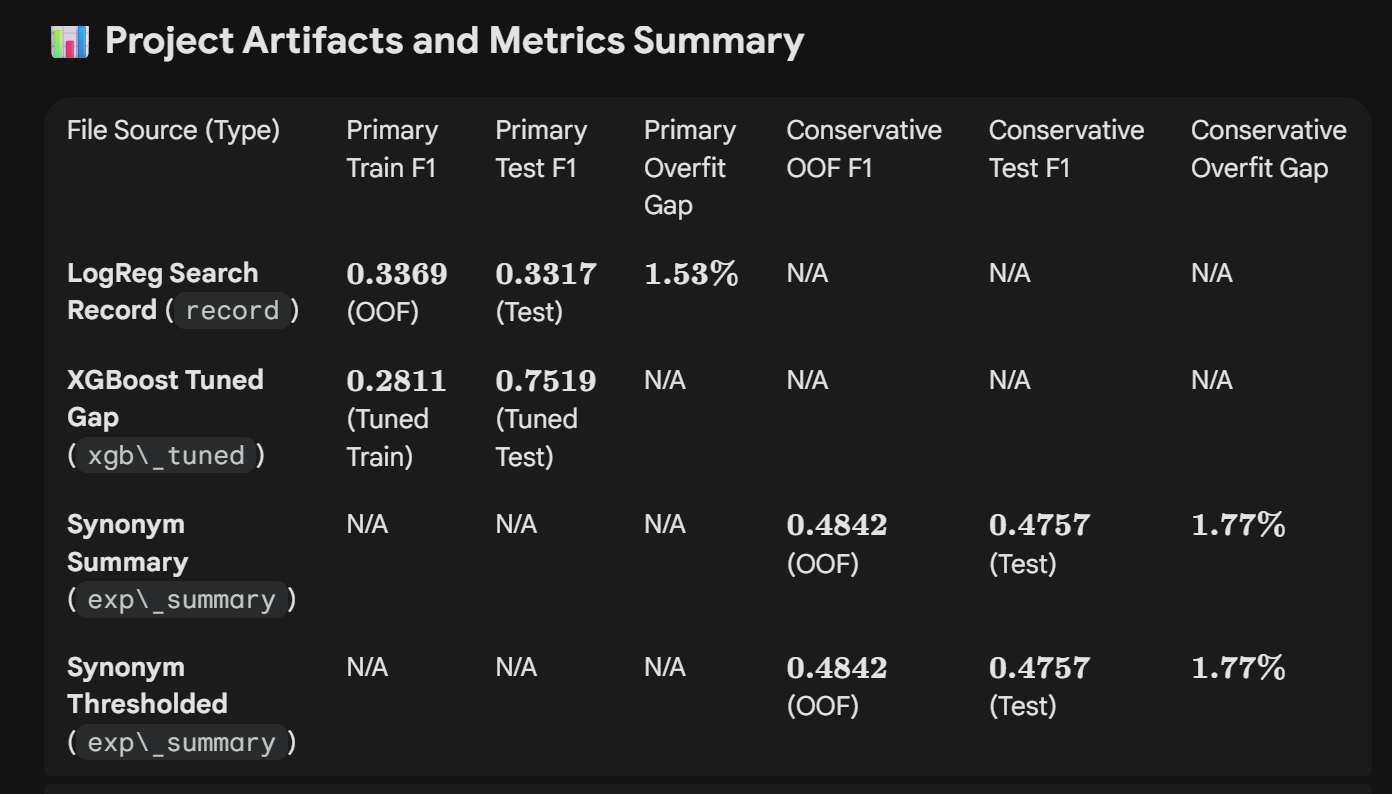